In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [2]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
from pathlib import Path

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score,
    silhouette_samples
)
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

## Data Overview

In [4]:
df = pd.read_csv("data/feature_engineered_data.csv")

In [7]:
warnings.filterwarnings('ignore')

In [8]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

In [9]:
CONFIG = {
    'random_state': 42,           # For reproducibility
    'figure_size': (12, 8),       # Default figure size
    'dpi': 300,                   # High-quality figures for thesis
    'colors': {
        'GCC': '#E74C3C',         # Red
        'Levant': '#3498DB',      # Blue  
        'North Africa': '#2ECC71', # Green
        'Other': '#F39C12'        # Orange
    }
}

In [10]:
np.random.seed(CONFIG['random_state'])

print("="*70)
print("  MENA GENDER DASHBOARD - ML PIPELINE")
print("="*70)
print("\n✓ Libraries imported successfully")
print(f"✓ Random seed set to: {CONFIG['random_state']}")


  MENA GENDER DASHBOARD - ML PIPELINE

✓ Libraries imported successfully
✓ Random seed set to: 42


In [12]:
print(f"\n📊 DATA SUMMARY:")
print(f"  • Countries: {df['country_name'].nunique()}")
print(f"  • Indicators: {df['indicator_name'].nunique()}")
print(f"  • Year range: {df['year'].min()} - {df['year'].max()}")
print(f"  • Regions: {df['region'].unique().tolist()}")


📊 DATA SUMMARY:
  • Countries: 18
  • Indicators: 42
  • Year range: 2000 - 2023
  • Regions: ['North Africa', 'GCC', 'Other', 'Levant']


In [13]:
df.isna().sum()

country_name                  0
year                          0
value                         0
indicator_id                  0
indicator_name                0
unit_type                     0
source                        0
source_reliable               0
region                        0
category                      0
val_num                       0
yoy_change                  756
yoy_pct_change            11215
yoy_pct_exists                0
rolling_mean_3y               0
rolling_std_3y             6966
rolling_mean_5y               0
rolling_std_5y             6966
cagr                       8295
spike                         0
dip                           0
outlier                       0
trend_slope                   0
coef_variation             3144
momentum                   5643
regional_deviation            0
regional_deviation_std        0
event_global               3024
event_country             15582
dtype: int64

In [14]:
base_cols = ['country_name', 'year', 'indicator_name', 'value', 'region', 'category','unit_type']
engineered_features = [col for col in df.columns if col not in base_cols]
    
print(f"\n🔧 ENGINEERED FEATURES DETECTED: {len(engineered_features)}")


🔧 ENGINEERED FEATURES DETECTED: 22


In [18]:
# Group by feature type
temporal_features = [f for f in engineered_features if any(
        x in f for x in ['yoy', 'rolling', 'growth', 'cagr']
    )]
shock_features = [f for f in engineered_features if any(
        x in f for x in ['spike', 'dip', 'outlier']
    )]
stability_features = [f for f in engineered_features if any(
        x in f for x in ['trend', 'slope', 'coef', 'momentum']
    )]
contextual_features = [f for f in engineered_features if any(
        x in f for x in ['regional', 'deviation']
    )]
    
print(f"\n  Temporal features ({len(temporal_features)}):")
for f in temporal_features[:20]:  # Show first 5
        print(f"    • {f}")

    
print(f"\n  Shock features ({len(shock_features)}):")
for f in shock_features:
        print(f"    • {f}")
    
print(f"\n  Stability features ({len(stability_features)}):")
for f in stability_features:
        print(f"    • {f}")
    
print(f"\n  Contextual features ({len(contextual_features)}):")
for f in contextual_features:
        print(f"    • {f}")
    



  Temporal features (8):
    • yoy_change
    • yoy_pct_change
    • yoy_pct_exists
    • rolling_mean_3y
    • rolling_std_3y
    • rolling_mean_5y
    • rolling_std_5y
    • cagr

  Shock features (3):
    • spike
    • dip
    • outlier

  Stability features (3):
    • trend_slope
    • coef_variation
    • momentum

  Contextual features (2):
    • regional_deviation
    • regional_deviation_std


## Data Prep for ML

In [19]:
w_df = (
    df
    .pivot_table(
        index=['country_name', 'year'],      # rows: country + year
        columns='indicator_name',           # columns: one per indicator
        values='val_num',                   # values: numeric indicator
        aggfunc='first'                     # if duplicates exist, take first
    )
)

# Make indicator names regular columns instead of MultiIndex
w_df = w_df.reset_index()

print(w_df.shape)
print("Countries:", w_df['country_name'].nunique())
print("Years:", w_df['year'].min(), "→", w_df['year'].max())


(432, 44)
Countries: 18
Years: 2000 → 2023


In [20]:
w_df.head()

indicator_name,country_name,year,A woman can apply for a passport in the same way as a man (1=yes; 0=no),"A woman can be ""head of household"" in the same way as a man (1=yes; 0=no)",A woman can choose where to live in the same way as a man (1=yes; 0=no),A woman can get a job in the same way as a man (1=yes; 0=no),A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no),A woman can open a bank account in the same way as a man (1=yes; 0=no),A woman can register a business in the same way as a man (1=yes; 0=no),A woman can sign a contract in the same way as a man (1=yes; 0=no),...,"Vulnerable employment, male (% of male employment) (modeled ILO estimate)",Women Business and the Law Index Score (scale 1-100),"Women, Business and the Law: Assets Indicator Score (scale 1-100)","Women, Business and the Law: Entrepreneurship Indicator Score (scale 1-100)","Women, Business and the Law: Marriage Indicator Score (scale 1-100)","Women, Business and the Law: Mobility Indicator Score (scale 1-100)","Women, Business and the Law: Parenthood Indicator Score (scale 1-100)","Women, Business and the Law: Pay Indicator Score (scale 1-100)","Women, Business and the Law: Pension Indicator Score (scale 1-100)","Women, Business and the Law: Workplace Indicator Score (scale 1-100)"
0,Algeria,2000,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,...,30.230035,40.625,40.0,75.0,0.0,50.0,60.0,50.0,25.0,25.0
1,Algeria,2001,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,...,30.227092,40.625,40.0,75.0,0.0,50.0,60.0,50.0,25.0,25.0
2,Algeria,2002,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,...,29.498284,40.625,40.0,75.0,0.0,50.0,60.0,50.0,25.0,25.0
3,Algeria,2003,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,...,28.639370,40.625,40.0,75.0,0.0,50.0,60.0,50.0,25.0,25.0
4,Algeria,2004,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,...,28.189026,40.625,40.0,75.0,0.0,50.0,60.0,50.0,25.0,25.0


### Country-level profiles (one row per country)

In [22]:
# Example: focus on SDG / post-Arab-Spring period
wide_focus = w_df[w_df['year'] >= 2010].copy()


In [23]:
# drop non-numeric columns for aggregation
indicator_cols = wide_focus.columns.difference(['country_name', 'year'])

# mean over time
country_mean = (
    wide_focus
    .groupby('country_name')[indicator_cols]
    .mean()
)

# add suffix to remember this is mean
country_mean = country_mean.add_suffix('_mean')

country_mean.head()


indicator_name,A woman can apply for a passport in the same way as a man (1=yes; 0=no)_mean,"A woman can be ""head of household"" in the same way as a man (1=yes; 0=no)_mean",A woman can choose where to live in the same way as a man (1=yes; 0=no)_mean,A woman can get a job in the same way as a man (1=yes; 0=no)_mean,A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)_mean,A woman can open a bank account in the same way as a man (1=yes; 0=no)_mean,A woman can register a business in the same way as a man (1=yes; 0=no)_mean,A woman can sign a contract in the same way as a man (1=yes; 0=no)_mean,A woman can travel outside her home in the same way as a man (1=yes; 0=no)_mean,A woman can travel outside the country in the same way as a man (1=yes; 0=no)_mean,...,"Vulnerable employment, male (% of male employment) (modeled ILO estimate)_mean",Women Business and the Law Index Score (scale 1-100)_mean,"Women, Business and the Law: Assets Indicator Score (scale 1-100)_mean","Women, Business and the Law: Entrepreneurship Indicator Score (scale 1-100)_mean","Women, Business and the Law: Marriage Indicator Score (scale 1-100)_mean","Women, Business and the Law: Mobility Indicator Score (scale 1-100)_mean","Women, Business and the Law: Parenthood Indicator Score (scale 1-100)_mean","Women, Business and the Law: Pay Indicator Score (scale 1-100)_mean","Women, Business and the Law: Pension Indicator Score (scale 1-100)_mean","Women, Business and the Law: Workplace Indicator Score (scale 1-100)_mean"
country_name,,,,,,,,,,,,,,,,,,,,,
Algeria,0.000000,1.000000,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,28.289890,56.428571,40.0,75.000000,51.428571,75.000000,60.000000,50.000000,25.000000,75.000000
Bahrain,1.000000,0.428571,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,1.030670,44.196429,40.0,82.142857,20.000000,50.000000,40.000000,23.214286,60.714286,37.500000
"Egypt, Arab Rep.",0.000000,0.000000,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,19.163498,43.973214,40.0,80.357143,4.285714,50.000000,20.000000,0.000000,100.000000,57.142857
"Iran, Islamic Rep.",0.000000,0.000000,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,39.760180,30.535714,40.0,75.000000,0.000000,0.000000,54.285714,50.000000,25.000000,0.000000
Iraq,0.571429,0.000000,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,26.311310,40.357143,40.0,78.571429,0.000000,14.285714,11.428571,39.285714,60.714286,78.571429


In [24]:
# sort so last() is really last year
wide_focus = wide_focus.sort_values(['country_name', 'year'])

country_last = (
    wide_focus
    .groupby('country_name')[indicator_cols]
    .last()
)

country_last = country_last.add_suffix('_last')

country_last.head()


indicator_name,A woman can apply for a passport in the same way as a man (1=yes; 0=no)_last,"A woman can be ""head of household"" in the same way as a man (1=yes; 0=no)_last",A woman can choose where to live in the same way as a man (1=yes; 0=no)_last,A woman can get a job in the same way as a man (1=yes; 0=no)_last,A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)_last,A woman can open a bank account in the same way as a man (1=yes; 0=no)_last,A woman can register a business in the same way as a man (1=yes; 0=no)_last,A woman can sign a contract in the same way as a man (1=yes; 0=no)_last,A woman can travel outside her home in the same way as a man (1=yes; 0=no)_last,A woman can travel outside the country in the same way as a man (1=yes; 0=no)_last,...,"Vulnerable employment, male (% of male employment) (modeled ILO estimate)_last",Women Business and the Law Index Score (scale 1-100)_last,"Women, Business and the Law: Assets Indicator Score (scale 1-100)_last","Women, Business and the Law: Entrepreneurship Indicator Score (scale 1-100)_last","Women, Business and the Law: Marriage Indicator Score (scale 1-100)_last","Women, Business and the Law: Mobility Indicator Score (scale 1-100)_last","Women, Business and the Law: Parenthood Indicator Score (scale 1-100)_last","Women, Business and the Law: Pay Indicator Score (scale 1-100)_last","Women, Business and the Law: Pension Indicator Score (scale 1-100)_last","Women, Business and the Law: Workplace Indicator Score (scale 1-100)_last"
country_name,,,,,,,,,,,,,,,,,,,,,
Algeria,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,28.236443,57.500,40.0,75.0,60.0,75.0,60.0,50.0,25.0,75.0
Bahrain,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,1.007825,68.125,40.0,100.0,40.0,50.0,40.0,100.0,100.0,75.0
"Egypt, Arab Rep.",0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,22.671914,50.625,40.0,100.0,20.0,50.0,20.0,0.0,100.0,75.0
"Iran, Islamic Rep.",0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,39.773023,31.250,40.0,75.0,0.0,0.0,60.0,50.0,25.0,0.0
Iraq,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,26.009439,48.125,40.0,100.0,0.0,25.0,20.0,50.0,50.0,100.0


In [25]:
country_std = (
    wide_focus
    .groupby('country_name')[indicator_cols]
    .std()
)
country_std = country_std.add_suffix('_std')


In [26]:
# Start with mean
country_profiles = country_mean.join(country_last, how='inner')

# If you want std too:
country_profiles = country_profiles.join(country_std, how='inner')

# Add region metadata (from original long df)
region_map = (
    df[['country_name', 'region']]
    .drop_duplicates()
    .set_index('country_name')
)

country_profiles = country_profiles.join(region_map, how='left')

country_profiles.head()
print(country_profiles.shape)


(18, 127)


In [27]:
country_profiles.head()

,A woman can apply for a passport in the same way as a man (1=yes; 0=no)_mean,"A woman can be ""head of household"" in the same way as a man (1=yes; 0=no)_mean",A woman can choose where to live in the same way as a man (1=yes; 0=no)_mean,A woman can get a job in the same way as a man (1=yes; 0=no)_mean,A woman can obtain a judgment of divorce in the same way as a man (1=yes; 0=no)_mean,A woman can open a bank account in the same way as a man (1=yes; 0=no)_mean,A woman can register a business in the same way as a man (1=yes; 0=no)_mean,A woman can sign a contract in the same way as a man (1=yes; 0=no)_mean,A woman can travel outside her home in the same way as a man (1=yes; 0=no)_mean,A woman can travel outside the country in the same way as a man (1=yes; 0=no)_mean,...,Women Business and the Law Index Score (scale 1-100)_std,"Women, Business and the Law: Assets Indicator Score (scale 1-100)_std","Women, Business and the Law: Entrepreneurship Indicator Score (scale 1-100)_std","Women, Business and the Law: Marriage Indicator Score (scale 1-100)_std","Women, Business and the Law: Mobility Indicator Score (scale 1-100)_std","Women, Business and the Law: Parenthood Indicator Score (scale 1-100)_std","Women, Business and the Law: Pay Indicator Score (scale 1-100)_std","Women, Business and the Law: Pension Indicator Score (scale 1-100)_std","Women, Business and the Law: Workplace Indicator Score (scale 1-100)_std",region
country_name,,,,,,,,,,,,,,,,,,,,,
Algeria,0.000000,1.000000,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,1.283881,0.0,0.000000,10.271052,0.000000,0.000000,0.000000,0.000000,0.000000,North Africa
Bahrain,1.000000,0.428571,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,13.948369,0.0,11.720181,19.215378,0.000000,0.000000,42.135639,18.898224,30.618622,GCC
"Egypt, Arab Rep.",0.000000,0.000000,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,...,4.603296,0.0,10.645383,8.516306,0.000000,0.000000,0.000000,0.000000,24.862258,North Africa
"Iran, Islamic Rep.",0.000000,0.000000,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,1.172018,0.0,0.000000,0.000000,0.000000,9.376145,0.000000,0.000000,0.000000,Other
Iraq,0.571429,0.000000,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,...,6.585761,0.0,9.078413,0.000000,12.838815,10.271052,12.838815,12.838815,25.677630,Other


In [31]:
# How much missingness is left?
print(country_profiles.isna().mean().sort_values(ascending=False))



A woman can apply for a passport in the same way as a man (1=yes; 0=no)_mean         0.0
Women, Business and the Law: Parenthood Indicator Score (scale 1-100)_last           0.0
A woman can travel outside the country in the same way as a man (1=yes; 0=no)_std    0.0
A woman can travel outside her home in the same way as a man (1=yes; 0=no)_std       0.0
A woman can sign a contract in the same way as a man (1=yes; 0=no)_std               0.0
                                                                                    ... 
Women, Business and the Law: Mobility Indicator Score (scale 1-100)_mean             0.0
Women, Business and the Law: Marriage Indicator Score (scale 1-100)_mean             0.0
Women, Business and the Law: Entrepreneurship Indicator Score (scale 1-100)_mean     0.0
Women, Business and the Law: Assets Indicator Score (scale 1-100)_mean               0.0
region                                                                               0.0
Length: 127, dtype: f

In [32]:
null_cols = country_profiles.columns[country_profiles.isna().any()].tolist()
null_cols

[]

## EXPLORATORY DATA ANALYSIS (EDA)

In [33]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler

#### Correlation Matrix (Top 30 Indicators)

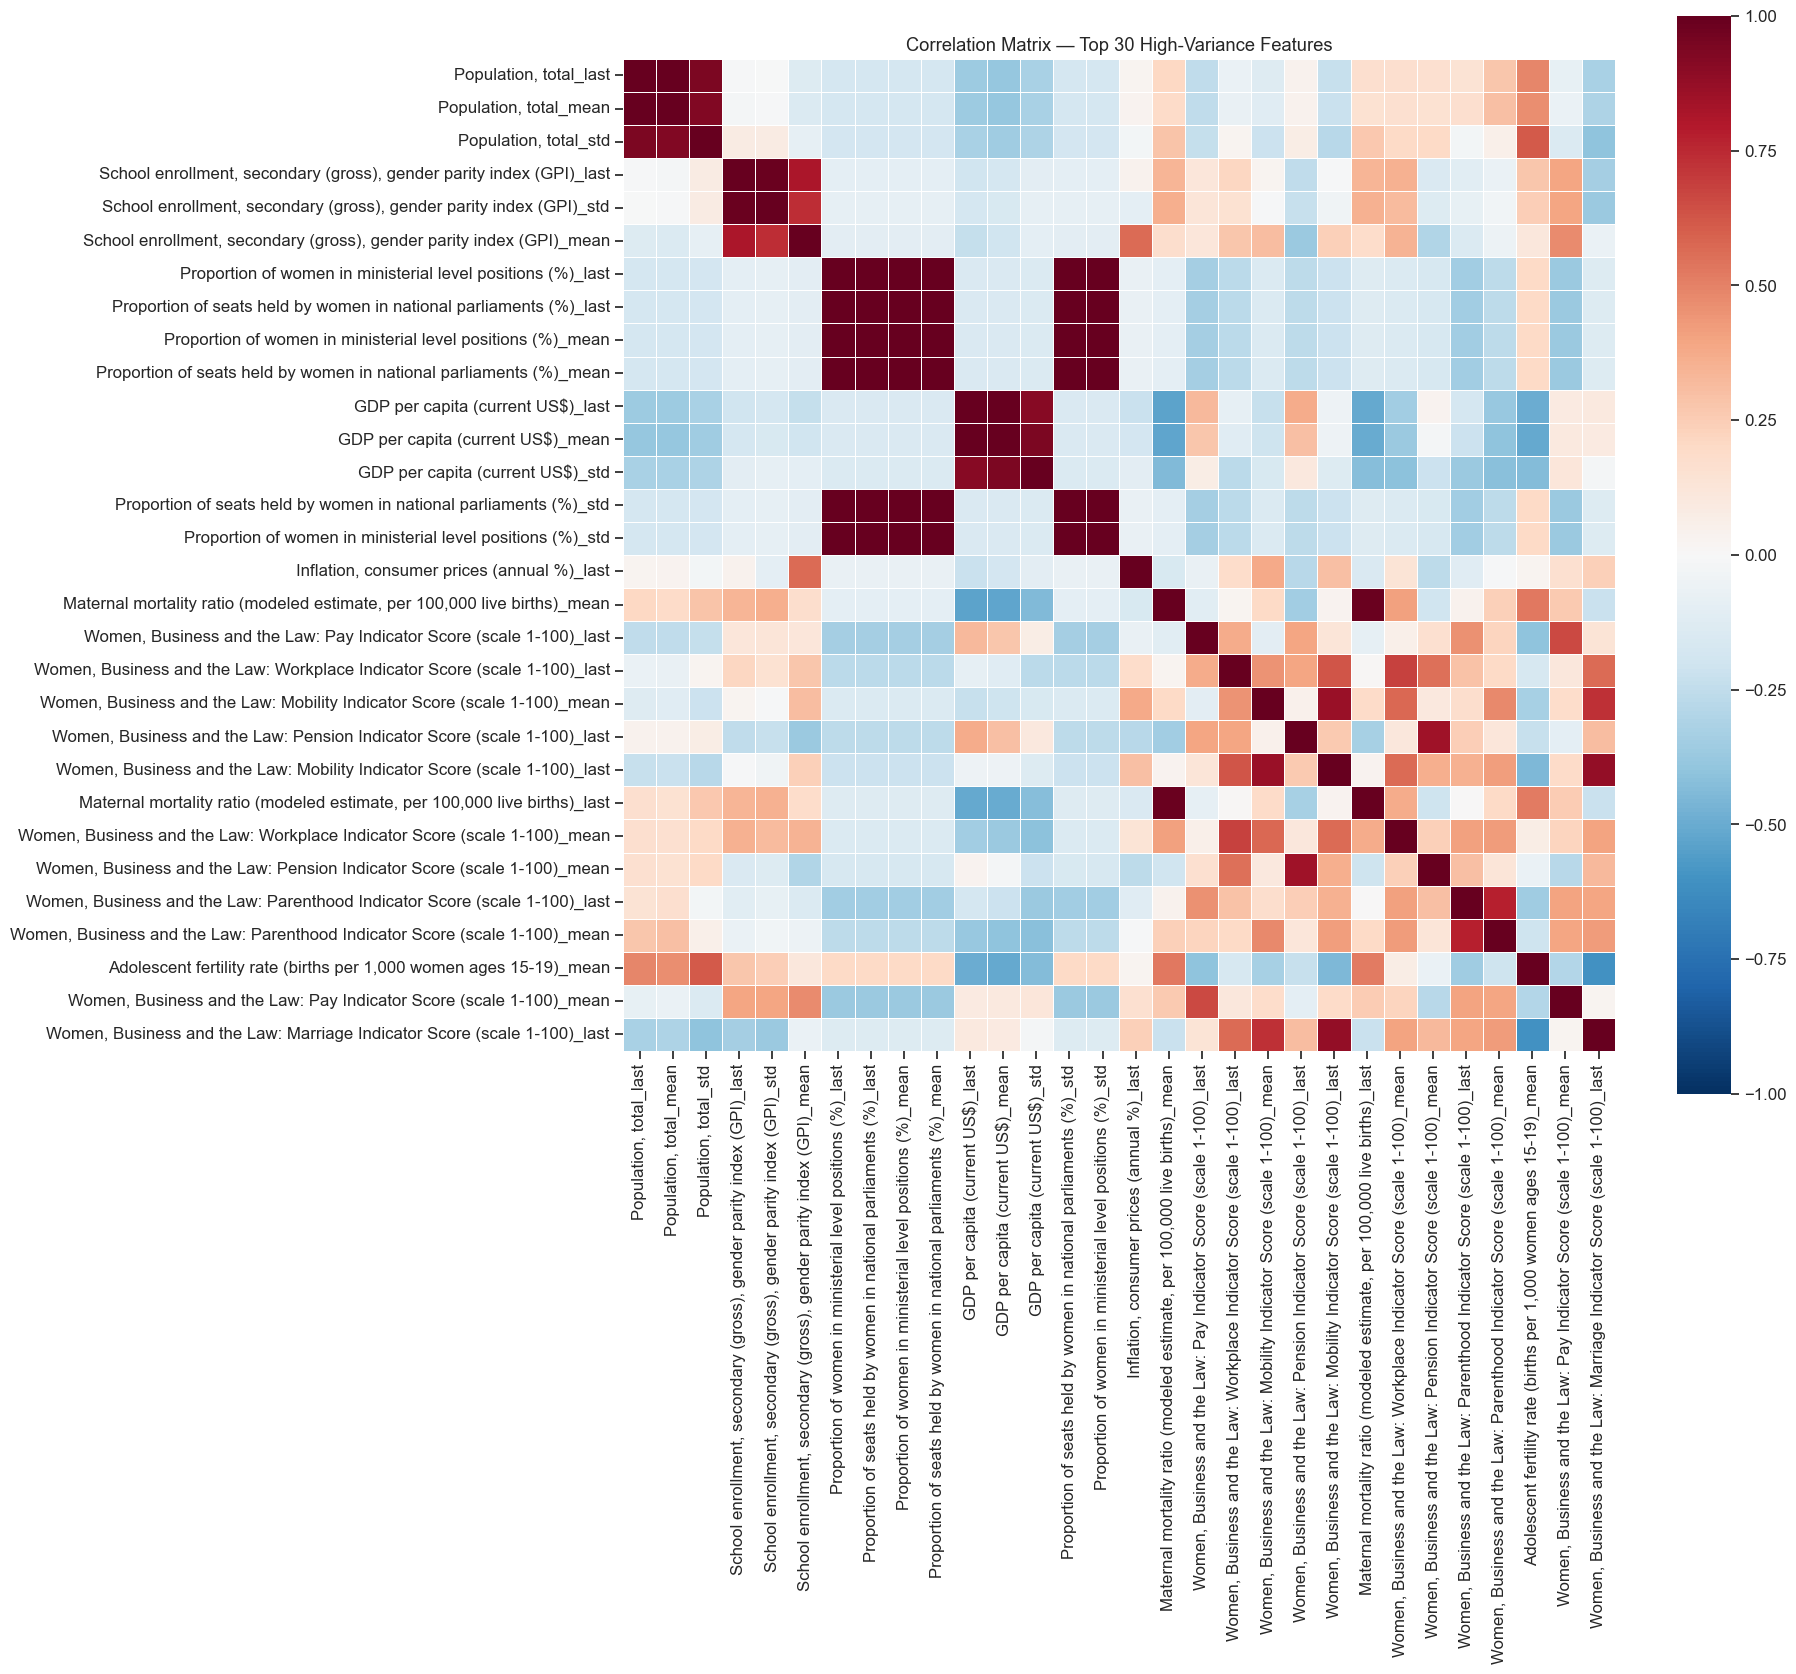

In [35]:
# numeric features only
numeric_cols = country_profiles.select_dtypes(include=[np.number]).columns

# select top 30 by variance — avoids clutter
top_features = country_profiles[numeric_cols].var().nlargest(30).index

corr = country_profiles[top_features].corr()

plt.figure(figsize=(16,14))
#mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)

plt.title("Correlation Matrix — Top 30 High-Variance Features")
plt.show()

In [38]:
country_profiles[numeric_cols].var().nlargest(50)

Population, total_last                                                                9.988605e+14
Population, total_mean                                                                8.158382e+14
Population, total_std                                                                 4.555975e+12
School enrollment, secondary (gross), gender parity index (GPI)_last                  1.602812e+11
School enrollment, secondary (gross), gender parity index (GPI)_std                   2.333761e+10
School enrollment, secondary (gross), gender parity index (GPI)_mean                  7.379776e+09
Proportion of women in ministerial level positions (%)_last                           4.368184e+09
Proportion of seats held by women in national parliaments (%)_last                    4.368156e+09
Proportion of women in ministerial level positions (%)_mean                           3.443474e+09
Proportion of seats held by women in national parliaments (%)_mean                    3.443379e+09
GDP per ca

In [41]:
# 1. List of features to KEEP for ML
ml_features = [
    'Population, total_mean',
    'GDP per capita (current US$)_mean',
    'School enrollment, secondary (gross), gender parity index (GPI)_mean',
    'Proportion of seats held by women in national parliaments (%)_mean',
    'Women Business and the Law Index Score (scale 1-100)_mean',
    'Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean',
    'Adolescent fertility rate (births per 1,000 women ages 15-19)_mean',
    'Inflation, consumer prices (annual %)_mean',
    'region',   # keep for later visualization but not for PCA
    #'country_name'   # optional, depending on your index
]

# 2. Subset your ML dataset
ml_df = country_profiles[ml_features].copy()

ml_df.head()


,"Population, total_mean",GDP per capita (current US$)_mean,"School enrollment, secondary (gross), gender parity index (GPI)_mean",Proportion of seats held by women in national parliaments (%)_mean,Women Business and the Law Index Score (scale 1-100)_mean,"Maternal mortality ratio (modeled estimate, per 100,000 live births)_mean","Adolescent fertility rate (births per 1,000 women ages 15-19)_mean","Inflation, consumer prices (annual %)_mean",region
country_name,,,,,,,,,
Algeria,4.122578e+07,4991.221498,1.038538,21.485630,56.428571,77.857143,9.756929,5.337271,North Africa
Bahrain,1.397187e+06,25991.901821,1.040759,11.607143,44.196429,14.857143,12.226643,1.271203,GCC
"Egypt, Arab Rep.",1.022794e+08,3117.834388,0.986903,15.138855,43.973214,26.142857,50.559214,13.004708,North Africa
"Iran, Islamic Rep.",8.414512e+07,5369.001800,0.959292,4.559862,30.535714,24.785714,32.936214,26.042604,Other
Iraq,3.856081e+07,5436.911634,198240.020355,26.306004,40.357143,83.357143,72.327214,1.444095,Other


In [42]:
ml_df["Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean"] = country_profiles["Employment to population ratio, 15+, female (%) (modeled ILO estimate)_mean"]
